# Logistics & Supply Chain Data Analysis

# Bivariate Analysis

Domain: Logistics & Supply Chain

Tools Used: Python, Pandas, NumPy, Jupyter Notebook

# Objective

The objective of this notebook is to analyse the relationship between two variables using statistical methods and visualisations. The analysis helps identify correlations, trends and patterns that support business decision-making.

# Import Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Importing all csv/tables regarding the dataset

In [2]:
discrepancy_log = pd.read_csv("C:\\My Data _____________________\\Data Analytics\\Project Datasets\\Logistics & Supply Chain – Inventory Management\inventory_discrepancy_log_large.csv")
inventory_item = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_item_master_large.csv")
inventory_kpi = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_kpi_summary_large.csv")
inventory_movement = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_movement_log_large.csv")
inventory_profiling = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_profiling_large.csv")
inventory_validation = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_validation_log_large.csv")
task_allocation = pd.read_csv("C:\\My Data _____________________\\Data Analytics\\Project Datasets\\Logistics & Supply Chain – Inventory Management\\task_allocation_log_large.csv")

1. Converting Inappropriate data type (if any)
2. Identifying Duplicated Values in column
3. Doing column wise Bi-Variate Analysis

# Dataset Overview

In [3]:
discrepancy_log.shape

(15336, 11)

In [4]:
task_allocation.sample(5)

,Task_ID,Task_Date,Item_ID,Warehouse_Code,Task_Type,Assigned_Staff,Assigned_Quantity,Task_Status
66481,TASK2066481,2021-06-29,ITEM136969,WH_NAG_01,Stock Transfer,staff_kiran,29,Completed
28644,TASK2028644,2022-06-20,ITEM134177,WH_BLR_01,Packing,staff_vikas,14,Completed
13378,TASK2013378,2024-12-21,ITEM119522,WH_NAG_01,Stock Transfer,staff_ajay,20,Completed
45477,TASK2045477,2024-10-01,ITEM121304,WH_DEL_01,Inbound Verification,staff_priya,11,Completed
73786,TASK2073786,2023-11-27,ITEM101139,WH_BLR_01,Picking,staff_priya,14,Completed


# Creating Reusable function

In [5]:
# Creating function to see the unique categories and its value_counts in that 
# particular column of the table.

def check_unique (table_name) :
    for col in table_name.columns :
        if table_name[col].nunique() < 20 :
            print (table_name[col].value_counts())
            print ("_" * 60)
            

In [6]:
discrepancy_log.head()

,Discrepancy_ID,Movement_ID,Item_ID,Warehouse_Code,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,Resolution_Status
0,DISC6000000,MOV3000004,ITEM122157,WH_NAG_01,23-07-24,30,27,-3,Wrong Item,Documentation missing,Resolved
1,DISC6000001,MOV3000012,ITEM125618,WH_BLR_01,07-11-22,10,17,7,Excess,Handling damage,Resolved
2,DISC6000002,MOV3000022,ITEM132861,WH_NAG_01,09-01-22,6,11,5,Wrong Item,Handling damage,Open
3,DISC6000003,MOV3000025,ITEM119139,WH_PUN_01,22-10-24,26,29,3,Shortage,Documentation missing,Under Investigation
4,DISC6000004,MOV3000033,ITEM133453,WH_NAG_01,01-08-21,39,43,4,Count Error,Vendor short supply,Open


In [7]:
discrepancy_log.shape

(15336, 11)

In [8]:
discrepancy_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15336 entries, 0 to 15335
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Discrepancy_ID     15336 non-null  object
 1   Movement_ID        15336 non-null  object
 2   Item_ID            15336 non-null  object
 3   Warehouse_Code     15336 non-null  object
 4   Discrepancy_Date   15336 non-null  object
 5   Expected_Quantity  15336 non-null  int64 
 6   Actual_Quantity    15336 non-null  int64 
 7   Variance_Quantity  15336 non-null  int64 
 8   Discrepancy_Type   15336 non-null  object
 9   Root_Cause         15336 non-null  object
 10  Resolution_Status  15336 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.3+ MB


In [9]:
discrepancy_log.isnull().sum()

Discrepancy_ID       0
Movement_ID          0
Item_ID              0
Warehouse_Code       0
Discrepancy_Date     0
Expected_Quantity    0
Actual_Quantity      0
Variance_Quantity    0
Discrepancy_Type     0
Root_Cause           0
Resolution_Status    0
dtype: int64

In [10]:
discrepancy_log['Discrepancy_Date'] = pd.DatetimeIndex(discrepancy_log['Discrepancy_Date'])

In [11]:
check_unique(discrepancy_log)

Warehouse_Code
WH_BLR_01    2652
WH_CHN_01    2598
WH_NAG_01    2560
WH_DEL_01    2553
WH_MUM_01    2504
WH_PUN_01    2469
Name: count, dtype: int64
____________________________________________________________
Discrepancy_Type
Damage         3135
Excess         3085
Shortage       3059
Count Error    3056
Wrong Item     3001
Name: count, dtype: int64
____________________________________________________________
Root_Cause
System posting delay     2621
Manual counting error    2589
Wrong bin placement      2562
Vendor short supply      2556
Handling damage          2548
Documentation missing    2460
Name: count, dtype: int64
____________________________________________________________
Resolution_Status
Resolved               4592
Under Investigation    3883
Open                   3793
Adjusted               3068
Name: count, dtype: int64
____________________________________________________________


In [12]:
discrepancy_log.head(2)

,Discrepancy_ID,Movement_ID,Item_ID,Warehouse_Code,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,Resolution_Status
0,DISC6000000,MOV3000004,ITEM122157,WH_NAG_01,2024-07-23,30,27,-3,Wrong Item,Documentation missing,Resolved
1,DISC6000001,MOV3000012,ITEM125618,WH_BLR_01,2022-07-11,10,17,7,Excess,Handling damage,Resolved


In [13]:
discrepancy_log.groupby('Warehouse_Code')['Expected_Quantity'].sum()

Warehouse_Code
WH_BLR_01    50496
WH_CHN_01    50419
WH_DEL_01    49375
WH_MUM_01    48757
WH_NAG_01    48154
WH_PUN_01    47712
Name: Expected_Quantity, dtype: int64

# Bivariate Visualizations

<Axes: xlabel='Expected_Quantity', ylabel='Warehouse_Code'>

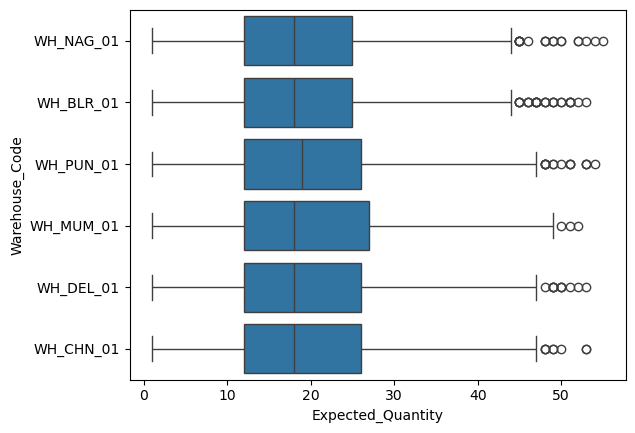

In [14]:
sns.boxplot(x = discrepancy_log['Expected_Quantity'], y=discrepancy_log['Warehouse_Code'])

In [15]:
discrepancy_log.groupby('Warehouse_Code')['Actual_Quantity'].sum()

Warehouse_Code
WH_BLR_01    50061
WH_CHN_01    49006
WH_DEL_01    48409
WH_MUM_01    47884
WH_NAG_01    47694
WH_PUN_01    46867
Name: Actual_Quantity, dtype: int64

<Axes: xlabel='Actual_Quantity', ylabel='Warehouse_Code'>

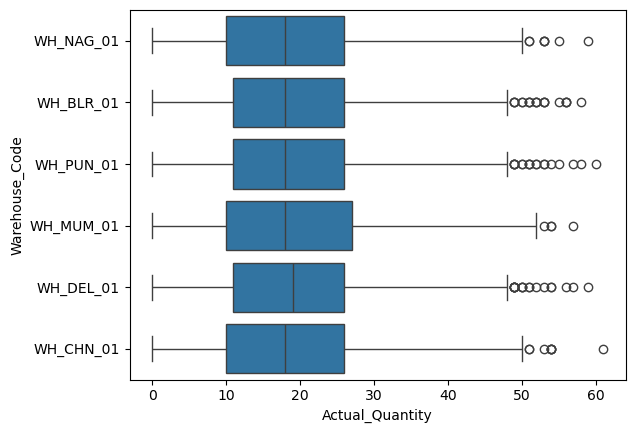

In [16]:
sns.boxplot(x = discrepancy_log['Actual_Quantity'], y=discrepancy_log['Warehouse_Code'])

In [17]:
discrepancy_log.groupby('Warehouse_Code')['Variance_Quantity'].sum()

Warehouse_Code
WH_BLR_01    -435
WH_CHN_01   -1413
WH_DEL_01    -966
WH_MUM_01    -873
WH_NAG_01    -460
WH_PUN_01    -845
Name: Variance_Quantity, dtype: int64

<Axes: xlabel='Warehouse_Code', ylabel='Variance_Quantity'>

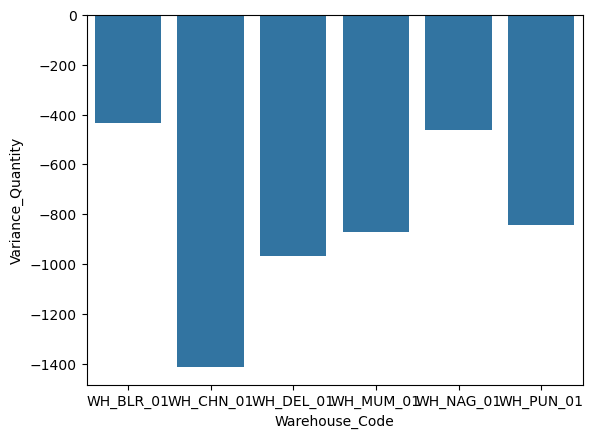

In [18]:
sns.barplot(discrepancy_log.groupby('Warehouse_Code')['Variance_Quantity'].sum())

In [19]:
pd.crosstab(discrepancy_log['Warehouse_Code'],discrepancy_log['Discrepancy_Type'])

Discrepancy_Type,Count Error,Damage,Excess,Shortage,Wrong Item
Warehouse_Code,,,,,
WH_BLR_01,547,546,529,531,499
WH_CHN_01,525,547,541,482,503
WH_DEL_01,496,529,511,494,523
WH_MUM_01,493,528,496,510,477
WH_NAG_01,515,502,488,552,503
WH_PUN_01,480,483,520,490,496


<Axes: xlabel='Discrepancy_Type', ylabel='Warehouse_Code'>

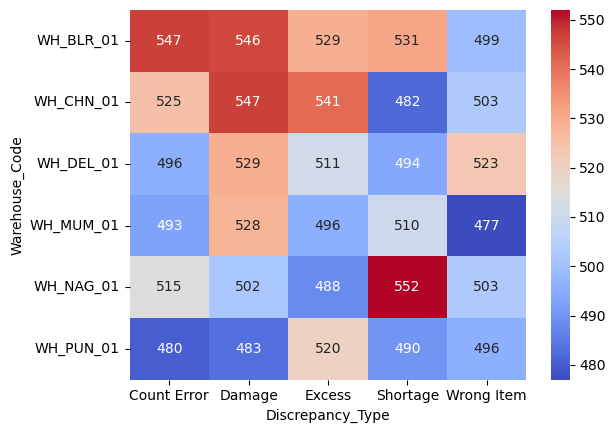

In [20]:
sns.heatmap(pd.crosstab(discrepancy_log['Warehouse_Code'],
                        discrepancy_log['Discrepancy_Type']),
                        annot=True,
                        fmt='d',
                        cmap='coolwarm')

In [21]:
pd.crosstab(discrepancy_log['Warehouse_Code'], discrepancy_log['Root_Cause'])

Root_Cause,Documentation missing,Handling damage,Manual counting error,System posting delay,Vendor short supply,Wrong bin placement
Warehouse_Code,,,,,,
WH_BLR_01,428,469,429,466,441,419
WH_CHN_01,388,415,461,458,431,445
WH_DEL_01,411,417,405,464,422,434
WH_MUM_01,407,442,428,398,412,417
WH_NAG_01,411,435,441,418,418,437
WH_PUN_01,415,370,425,417,432,410


## Correlation Heatmap

<Axes: xlabel='Warehouse_Code', ylabel='Root_Cause'>

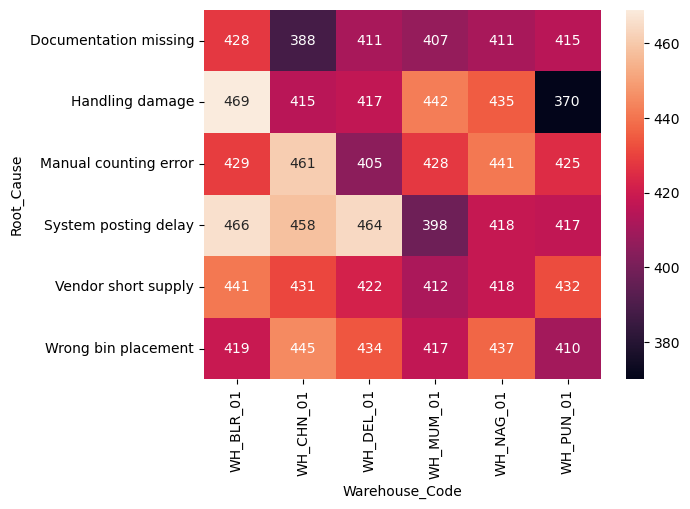

In [22]:
sns.heatmap(pd.crosstab(discrepancy_log['Root_Cause'], discrepancy_log['Warehouse_Code']),
            annot=True, fmt = 'd' ,)

In [23]:
pd.crosstab(discrepancy_log['Warehouse_Code'], discrepancy_log['Resolution_Status'])

Resolution_Status,Adjusted,Open,Resolved,Under Investigation
Warehouse_Code,,,,
WH_BLR_01,528,649,781,694
WH_CHN_01,554,611,813,620
WH_DEL_01,511,675,735,632
WH_MUM_01,497,618,730,659
WH_NAG_01,490,637,789,644
WH_PUN_01,488,603,744,634


<Axes: xlabel='Warehouse_Code', ylabel='Resolution_Status'>

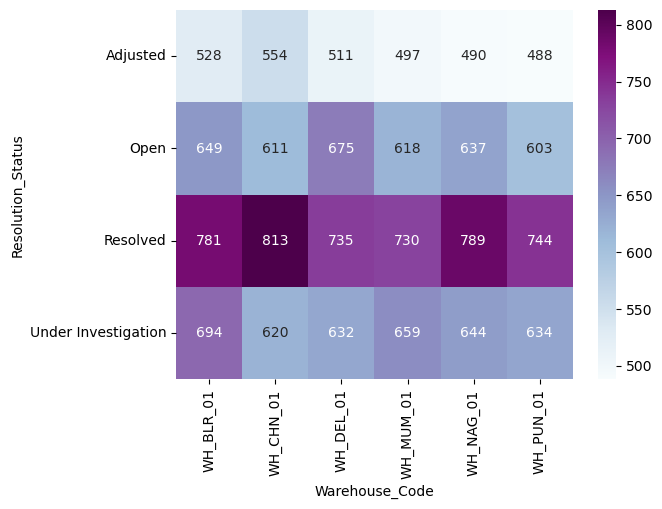

In [24]:
sns.heatmap (pd.crosstab(discrepancy_log['Resolution_Status'], discrepancy_log['Warehouse_Code']),
            annot = True, fmt = "d", cmap="BuPu")

In [25]:
discrepancy_log["Year"] = discrepancy_log['Discrepancy_Date'].dt.year

In [26]:
pd.crosstab(discrepancy_log["Year"], discrepancy_log['Warehouse_Code'])

Warehouse_Code,WH_BLR_01,WH_CHN_01,WH_DEL_01,WH_MUM_01,WH_NAG_01,WH_PUN_01
Year,,,,,,
2021,678,647,714,609,631,615
2022,659,680,620,649,664,661
2023,667,655,620,629,646,594
2024,648,616,599,617,619,599


In [27]:
pd.crosstab(discrepancy_log['Resolution_Status'], discrepancy_log['Discrepancy_Type'])

Discrepancy_Type,Count Error,Damage,Excess,Shortage,Wrong Item
Resolution_Status,,,,,
Adjusted,604,619,642,606,597
Open,788,754,771,743,737
Resolved,905,961,906,922,898
Under Investigation,759,801,766,788,769


## Comparative Box Plot

<Axes: xlabel='Resolution_Status', ylabel='Discrepancy_Type'>

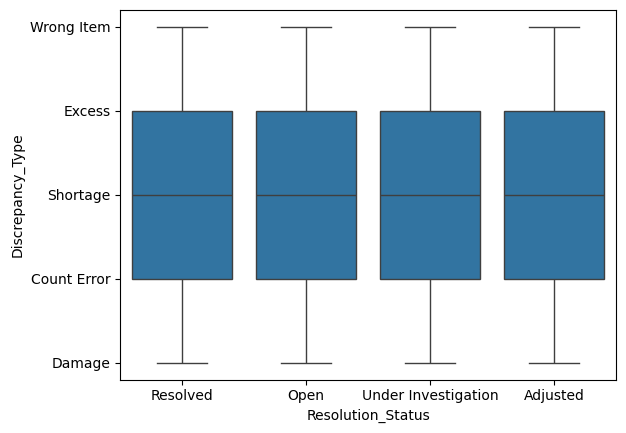

In [28]:
sns.boxplot(discrepancy_log, x ='Resolution_Status',
             y = 'Discrepancy_Type')

<Axes: xlabel='Discrepancy_Type', ylabel='count'>

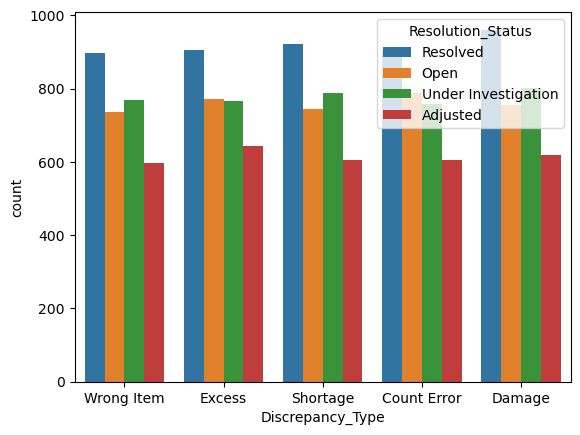

In [29]:
sns.countplot(discrepancy_log, x ='Discrepancy_Type',
             hue = 'Resolution_Status')

In [30]:
variance_count = discrepancy_log['Variance_Quantity'].sum()

In [31]:
discrepancy_log.groupby('Discrepancy_Type')['Variance_Quantity'].sum()

Discrepancy_Type
Count Error   -1123
Damage        -1279
Excess         -997
Shortage       -777
Wrong Item     -816
Name: Variance_Quantity, dtype: int64

<Axes: xlabel='Discrepancy_Type', ylabel='Variance_Quantity'>

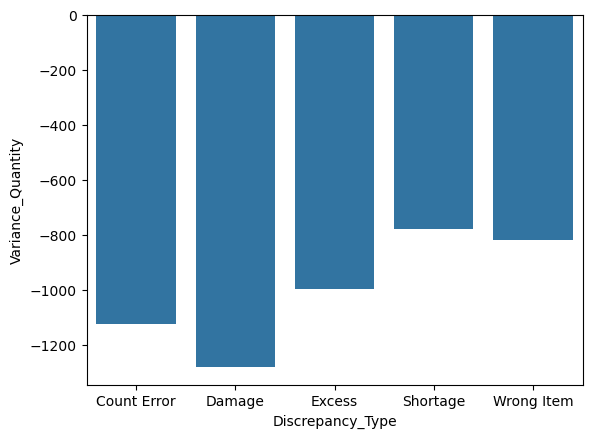

In [32]:
sns.barplot(discrepancy_log.groupby('Discrepancy_Type')['Variance_Quantity'].sum())

In [33]:
discrepancy_log.groupby('Root_Cause')['Variance_Quantity'].sum()

Root_Cause
Documentation missing   -925
Handling damage         -965
Manual counting error   -541
System posting delay    -988
Vendor short supply     -638
Wrong bin placement     -935
Name: Variance_Quantity, dtype: int64

In [34]:
discrepancy_log.groupby('Root_Cause')['Variance_Quantity'].agg(['sum', 'mean', 'min','max'])

,sum,mean,min,max
Root_Cause,,,,
Documentation missing,-925,-0.376016,-10,9
Handling damage,-965,-0.378728,-10,9
Manual counting error,-541,-0.208961,-10,9
System posting delay,-988,-0.376955,-10,9
Vendor short supply,-638,-0.249609,-10,9
Wrong bin placement,-935,-0.364949,-10,9


<Axes: xlabel='Root_Cause', ylabel='Variance_Quantity'>

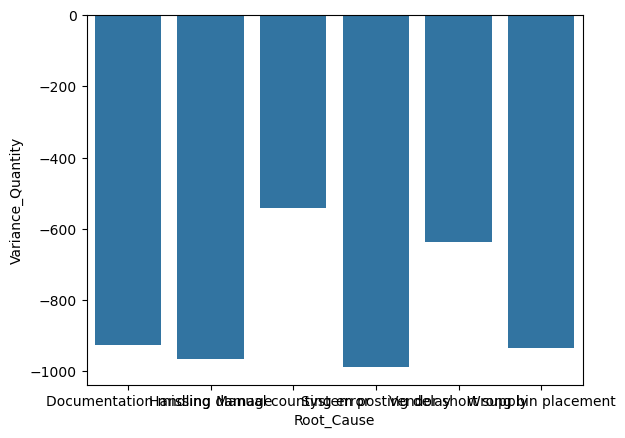

In [35]:
sns.barplot(discrepancy_log.groupby('Root_Cause')['Variance_Quantity'].sum())

# Bivariate Analysis of 2nd Table - "inventory_item"

In [36]:
inventory_item.head(3)

,Item_ID,Item_Description,Item_Category,Priority_Level,UOM,Warehouse_Code,Warehouse_City,Active_Flag
0,ITEM100000,Inventory Item 1,Packaging,Low,Kg,WH_BLR_01,Bangalore,Yes
1,ITEM100001,Inventory Item 2,Packaging,Medium,Pallet,WH_MUM_01,Mumbai,No
2,ITEM100002,Inventory Item 3,Finished Goods,High,Nos,WH_PUN_01,Pune,No


In [37]:
inventory_item.shape

(40000, 8)

In [38]:
inventory_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Item_ID           40000 non-null  object
 1   Item_Description  40000 non-null  object
 2   Item_Category     40000 non-null  object
 3   Priority_Level    40000 non-null  object
 4   UOM               40000 non-null  object
 5   Warehouse_Code    40000 non-null  object
 6   Warehouse_City    40000 non-null  object
 7   Active_Flag       40000 non-null  object
dtypes: object(8)
memory usage: 2.4+ MB


In [39]:
pd.crosstab(inventory_item['Item_Category'], inventory_item['Priority_Level'])

Priority_Level,High,Low,Medium
Item_Category,,,
Consumables,1209,1007,1813
Finished Goods,3799,3156,5801
Packaging,2196,1769,3300
Raw Material,3339,2811,4985
Spare Parts,1436,1202,2177


<Axes: xlabel='Priority_Level', ylabel='Item_Category'>

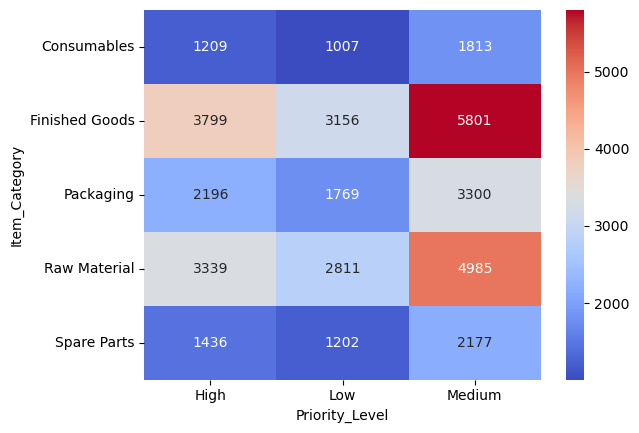

In [40]:
sns.heatmap(pd.crosstab(inventory_item['Item_Category'], inventory_item['Priority_Level']),
           annot = True, fmt = "d", cmap = 'coolwarm')

In [41]:
pd.crosstab(inventory_item['Warehouse_City'], inventory_item['Item_Category'])

Item_Category,Consumables,Finished Goods,Packaging,Raw Material,Spare Parts
Warehouse_City,,,,,
Bangalore,698,2173,1191,1831,807
Chennai,697,2032,1219,1843,795
Delhi,639,2199,1238,1875,794
Mumbai,684,2098,1264,1866,816
Nagpur,684,2203,1175,1831,782
Pune,627,2051,1178,1889,821


<Axes: xlabel='Warehouse_City', ylabel='Item_Category'>

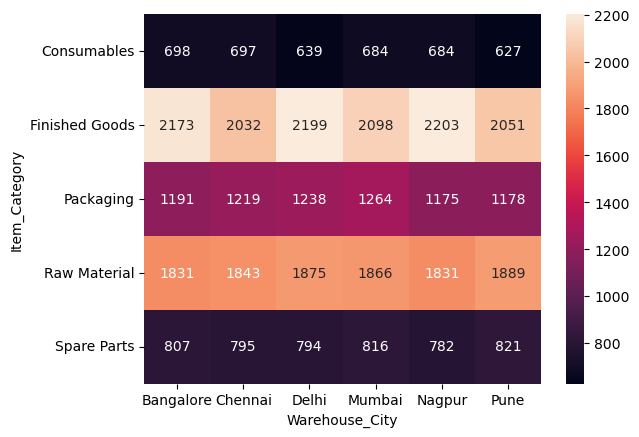

In [42]:
sns.heatmap(pd.crosstab(inventory_item['Item_Category'], inventory_item['Warehouse_City']),
           annot = True, fmt = 'd')

In [43]:
pd.crosstab(inventory_item['Item_Category'], inventory_item['Active_Flag'])

Active_Flag,No,Yes
Item_Category,,
Consumables,984,3045
Finished Goods,3210,9546
Packaging,1820,5445
Raw Material,2820,8315
Spare Parts,1186,3629


<Axes: xlabel='Item_Category'>

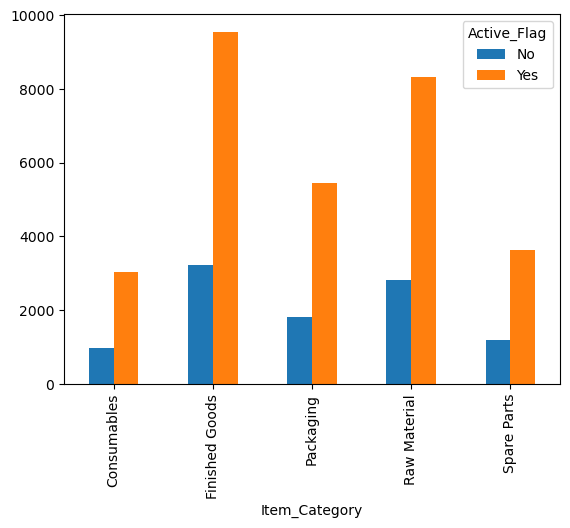

In [44]:
pd.crosstab(inventory_item['Item_Category'], inventory_item['Active_Flag']).plot(kind="bar")

In [45]:
pd.crosstab(inventory_item['Priority_Level'], inventory_item['Warehouse_City'])

Warehouse_City,Bangalore,Chennai,Delhi,Mumbai,Nagpur,Pune
Priority_Level,,,,,,
High,1968,2032,2043,2035,1936,1965
Low,1688,1595,1659,1699,1703,1601
Medium,3044,2959,3043,2994,3036,3000


# Bivariate Analysis of 3rd Table - "inventory_kpi"

In [46]:
inventory_kpi['Year_Month'] = pd.DatetimeIndex(inventory_kpi['Year_Month'])

In [47]:
inventory_kpi.head(3)

,Year_Month,Warehouse_Code,Tasks_Assigned,Tasks_Completed,Avg_Assigned_Qty,Total_Movements,Inward_Movements,Outward_Movements,Total_Quantity_Moved,Mismatch_Count,Discrepancy_Count,Total_Variance,Validations_Done,Validation_Failures,Task_Completion_Rate_%,Mismatch_Rate_%,Validation_Failure_Rate_%
0,2021-01-01,WH_BLR_01,319,273,20.605016,437,216,221,8580,47,58,-61,407,86,85.58,10.76,21.13
1,2021-01-01,WH_CHN_01,350,294,20.985714,408,193,215,7756,42,52,-41,407,86,84.00,10.29,21.13
2,2021-01-01,WH_DEL_01,350,306,20.468571,451,232,219,8565,44,56,-35,407,86,87.43,9.76,21.13


In [48]:
inventory_kpi.shape

(288, 17)

In [49]:
inventory_kpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Year_Month                 288 non-null    datetime64[ns]
 1   Warehouse_Code             288 non-null    object        
 2   Tasks_Assigned             288 non-null    int64         
 3   Tasks_Completed            288 non-null    int64         
 4   Avg_Assigned_Qty           288 non-null    float64       
 5   Total_Movements            288 non-null    int64         
 6   Inward_Movements           288 non-null    int64         
 7   Outward_Movements          288 non-null    int64         
 8   Total_Quantity_Moved       288 non-null    int64         
 9   Mismatch_Count             288 non-null    int64         
 10  Discrepancy_Count          288 non-null    int64         
 11  Total_Variance             288 non-null    int64         
 12  Validati

In [50]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Assigned'].sum()

Warehouse_Code
WH_BLR_01    16821
WH_CHN_01    16631
WH_DEL_01    16619
WH_MUM_01    16706
WH_NAG_01    16826
WH_PUN_01    16397
Name: Tasks_Assigned, dtype: int64

array([<Axes: ylabel='Tasks_Assigned'>], dtype=object)

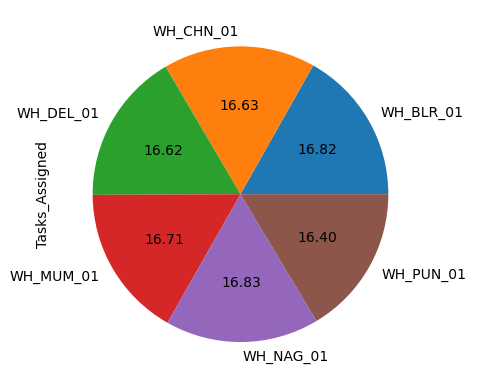

In [51]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Assigned'].sum().plot(kind="pie",
                                                                     autopct = "%0.2f",subplots=True)

<Axes: xlabel='Warehouse_Code', ylabel='Tasks_Assigned'>

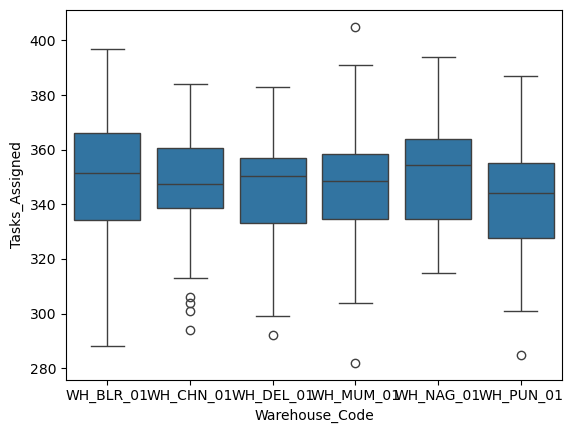

In [52]:
sns.boxplot (x=inventory_kpi['Warehouse_Code'], y=inventory_kpi['Tasks_Assigned'])

In [53]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Completed'].sum()

Warehouse_Code
WH_BLR_01    14206
WH_CHN_01    14145
WH_DEL_01    14096
WH_MUM_01    14181
WH_NAG_01    14310
WH_PUN_01    13959
Name: Tasks_Completed, dtype: int64

array([<Axes: ylabel='Tasks_Completed'>], dtype=object)

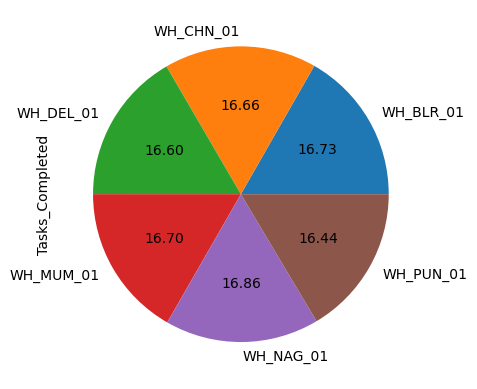

In [54]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Completed'].sum().plot(kind="pie",
                                                                     autopct = "%0.2f",subplots=True)

<Axes: xlabel='Tasks_Completed', ylabel='Warehouse_Code'>

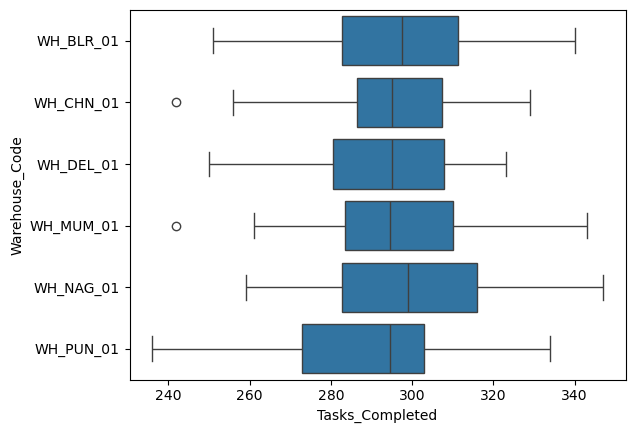

In [55]:
sns.boxplot (x=inventory_kpi['Tasks_Completed'], y=inventory_kpi['Warehouse_Code'])

In [56]:
inventory_kpi.groupby('Warehouse_Code')['Avg_Assigned_Qty'].sum()

Warehouse_Code
WH_BLR_01    961.561763
WH_CHN_01    975.873399
WH_DEL_01    969.190736
WH_MUM_01    969.464539
WH_NAG_01    953.773511
WH_PUN_01    974.415760
Name: Avg_Assigned_Qty, dtype: float64

<Axes: xlabel='Avg_Assigned_Qty', ylabel='Warehouse_Code'>

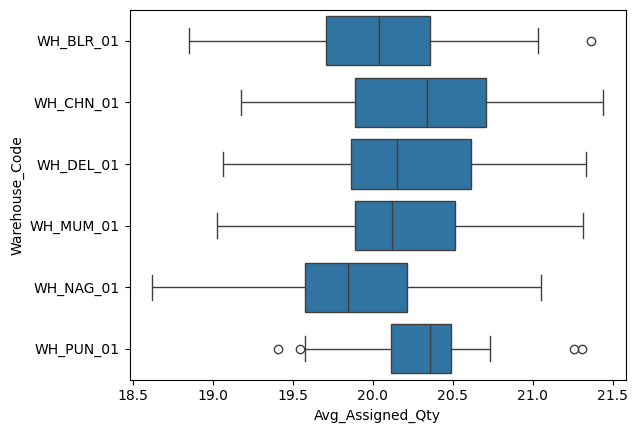

In [57]:
sns.boxplot (x=inventory_kpi['Avg_Assigned_Qty'], y=inventory_kpi['Warehouse_Code'])

<Axes: xlabel='Warehouse_Code'>

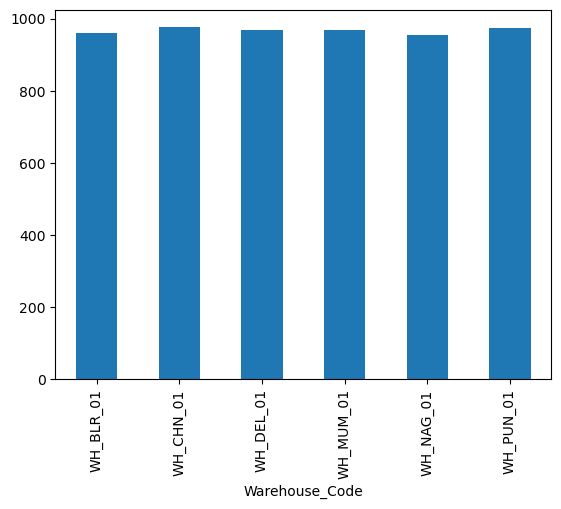

In [58]:
inventory_kpi.groupby('Warehouse_Code')['Avg_Assigned_Qty'].sum().plot(kind='bar')

In [59]:
inventory_kpi.groupby('Warehouse_Code')['Total_Movements']

<Axes: ylabel='Total_Movements'>

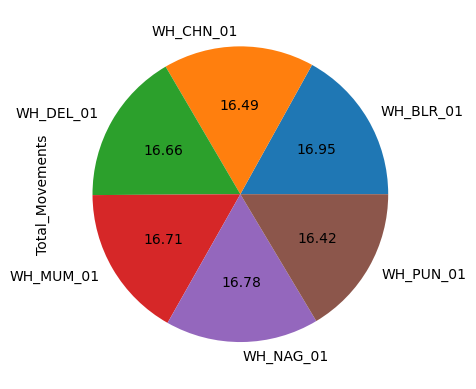

In [60]:
inventory_kpi.groupby('Warehouse_Code')['Total_Movements'].sum().plot(kind='pie',autopct="%0.2f")

<Axes: xlabel='Total_Movements', ylabel='Warehouse_Code'>

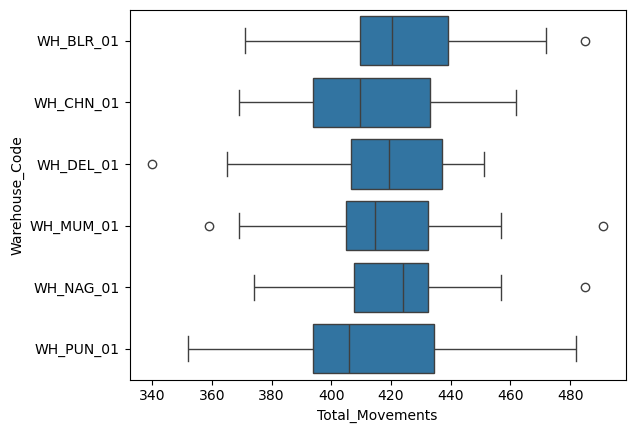

In [61]:
sns.boxplot(inventory_kpi, 
           x = inventory_kpi['Total_Movements'],
           y = inventory_kpi['Warehouse_Code'])

In [62]:
inventory_kpi.groupby('Warehouse_Code')['Inward_Movements'].sum()

Warehouse_Code
WH_BLR_01    9812
WH_CHN_01    9494
WH_DEL_01    9601
WH_MUM_01    9599
WH_NAG_01    9742
WH_PUN_01    9430
Name: Inward_Movements, dtype: int64

<Axes: ylabel='Inward_Movements'>

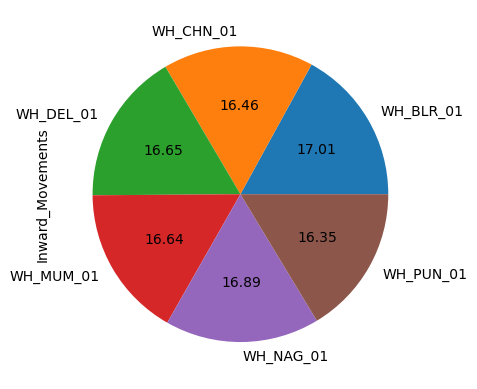

In [63]:
inventory_kpi.groupby('Warehouse_Code')['Inward_Movements'].sum().plot(kind='pie',autopct="%0.2f")

<Axes: xlabel='Warehouse_Code', ylabel='Inward_Movements'>

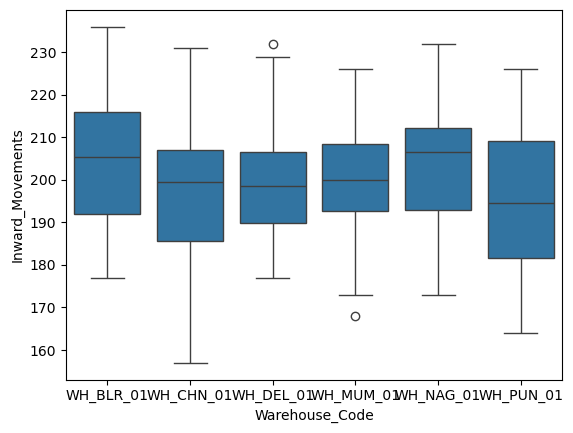

In [64]:
sns.boxplot(inventory_kpi, 
           x = inventory_kpi['Warehouse_Code'],
           y = inventory_kpi['Inward_Movements'])

In [65]:
inventory_kpi.groupby('Warehouse_Code')['Outward_Movements'].sum()

Warehouse_Code
WH_BLR_01    10523
WH_CHN_01    10294
WH_DEL_01    10392
WH_MUM_01    10453
WH_NAG_01    10392
WH_PUN_01    10268
Name: Outward_Movements, dtype: int64

<Axes: ylabel='Outward_Movements'>

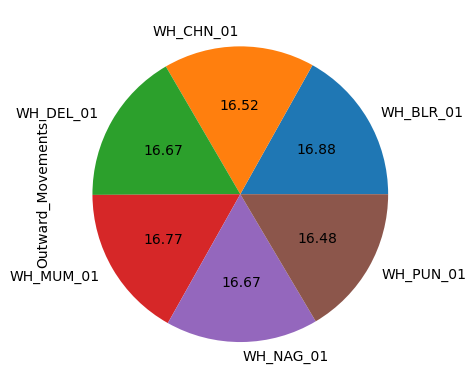

In [66]:
inventory_kpi.groupby('Warehouse_Code')['Outward_Movements'].sum().plot(kind='pie',autopct="%0.2f")

<Axes: xlabel='Outward_Movements', ylabel='Warehouse_Code'>

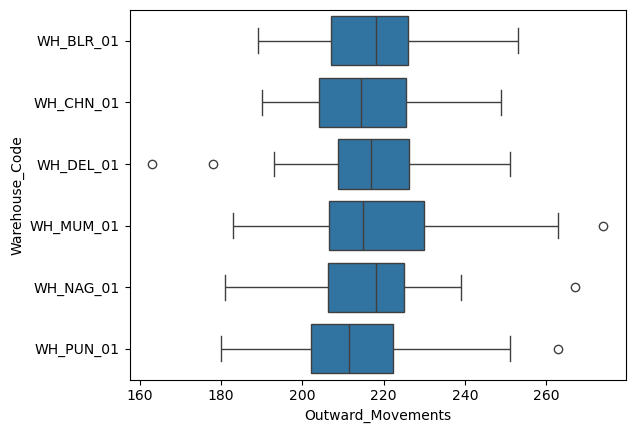

In [67]:
sns.boxplot(x=inventory_kpi['Outward_Movements'],y=inventory_kpi['Warehouse_Code'])

<Axes: xlabel='Tasks_Assigned', ylabel='Tasks_Completed'>

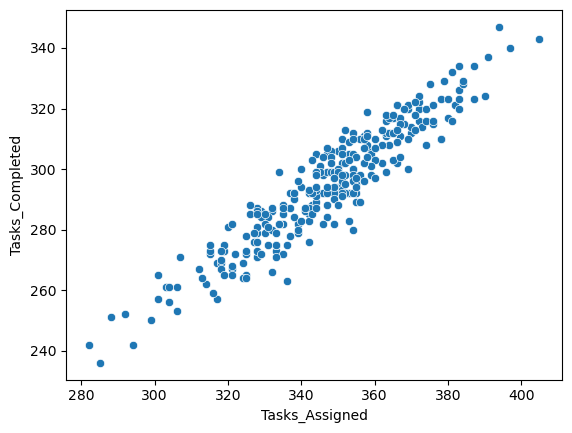

In [68]:
sns.scatterplot(x=inventory_kpi['Tasks_Assigned'], y=inventory_kpi['Tasks_Completed'])

<Axes: xlabel='Total_Movements', ylabel='Inward_Movements'>

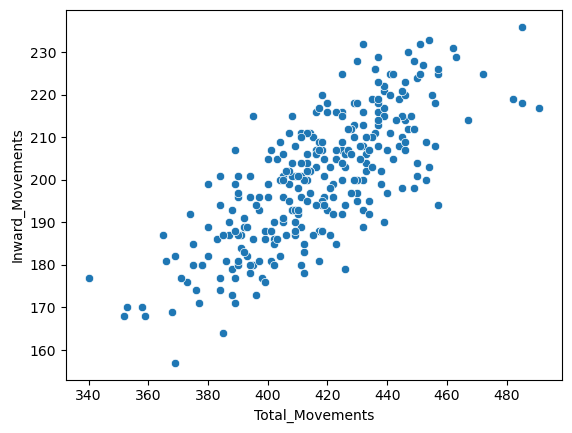

In [69]:
sns.scatterplot(x=inventory_kpi['Total_Movements'], y=inventory_kpi['Inward_Movements'])

<Axes: xlabel='Total_Movements', ylabel='Outward_Movements'>

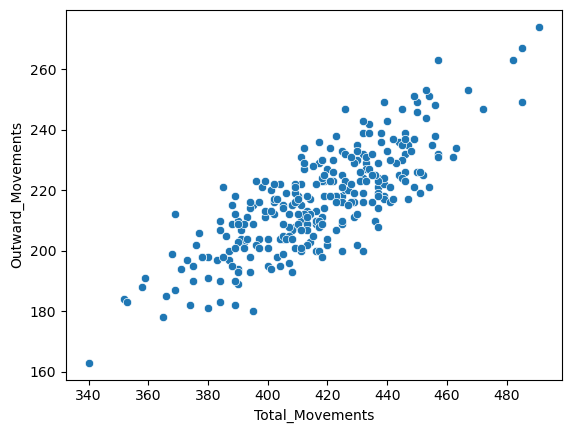

In [70]:
sns.scatterplot(x=inventory_kpi['Total_Movements'], y=inventory_kpi['Outward_Movements'])

# Bivariate Analysis of 4th Table - "inventory_movement"

In [71]:
inventory_movement.head(2)

,Movement_ID,Movement_Date,Item_ID,Warehouse_Code,Task_ID,Movement_Type,Movement_Quantity,Source,Destination,Verification_Status
0,MOV3000000,2021-10-24,ITEM127431,WH_DEL_01,TASK2054000,Inward,17,Return,Plant,Verified
1,MOV3000001,2024-03-09,ITEM138426,WH_CHN_01,TASK2039625,Inward,9,Plant,Customer,Verified


In [72]:
inventory_movement.shape

(120000, 10)

In [73]:
inventory_movement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Movement_ID          120000 non-null  object
 1   Movement_Date        120000 non-null  object
 2   Item_ID              120000 non-null  object
 3   Warehouse_Code       120000 non-null  object
 4   Task_ID              120000 non-null  object
 5   Movement_Type        120000 non-null  object
 6   Movement_Quantity    120000 non-null  int64 
 7   Source               120000 non-null  object
 8   Destination          120000 non-null  object
 9   Verification_Status  120000 non-null  object
dtypes: int64(1), object(9)
memory usage: 9.2+ MB


In [74]:
inventory_movement['Movement_Date'] = pd.DatetimeIndex(inventory_movement['Movement_Date'])

In [75]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Movement_Type']).agg(['sum'])

Movement_Type,Inward,Outward
sum,57678,62322


In [76]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Movement_Type'])

Movement_Type,Inward,Outward
Warehouse_Code,,
WH_BLR_01,9812,10523
WH_CHN_01,9494,10294
WH_DEL_01,9601,10392
WH_MUM_01,9599,10453
WH_NAG_01,9742,10392
WH_PUN_01,9430,10268


<Axes: xlabel='Movement_Type', ylabel='Warehouse_Code'>

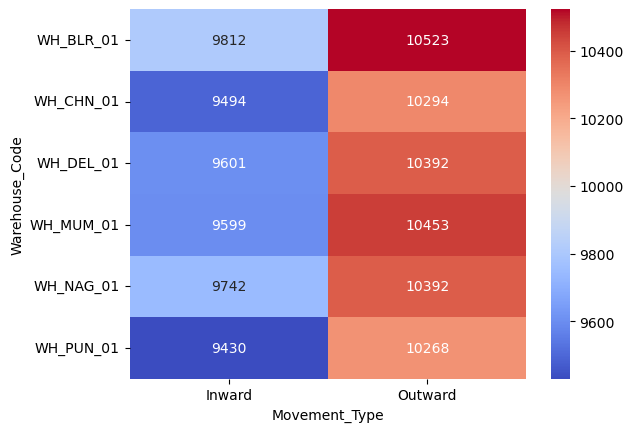

In [77]:
sns.heatmap(pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Movement_Type']),
           fmt = 'd', annot = True, cmap='coolwarm')

In [78]:
inventory_movement.groupby('Warehouse_Code')['Movement_Quantity'].sum()

Warehouse_Code
WH_BLR_01    396314
WH_CHN_01    390647
WH_DEL_01    393018
WH_MUM_01    394792
WH_NAG_01    389924
WH_PUN_01    388589
Name: Movement_Quantity, dtype: int64

In [79]:
inventory_movement['Movement_Quantity'].median()

19.0

<Axes: xlabel='Movement_Quantity', ylabel='Warehouse_Code'>

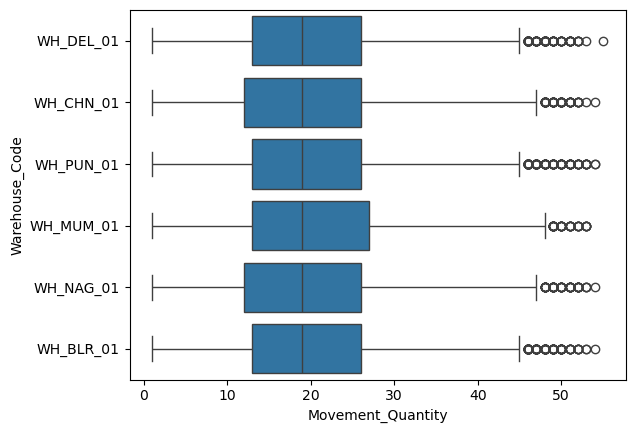

In [80]:
sns.boxplot(x=inventory_movement['Movement_Quantity'],y=inventory_movement['Warehouse_Code'] )

In [81]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Source']).agg(['sum'])

Source,Plant,Return,Vendor
sum,40030,40116,39854


<Axes: xlabel='Source', ylabel='Warehouse_Code'>

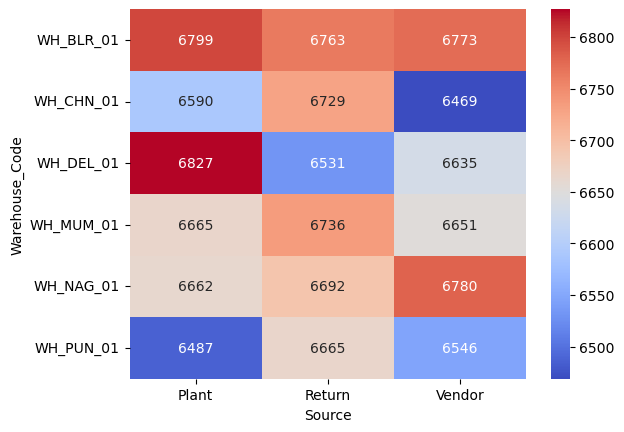

In [82]:
sns.heatmap(pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Source']),
           fmt = 'd', annot = True, cmap='coolwarm')

<Axes: xlabel='Warehouse_Code'>

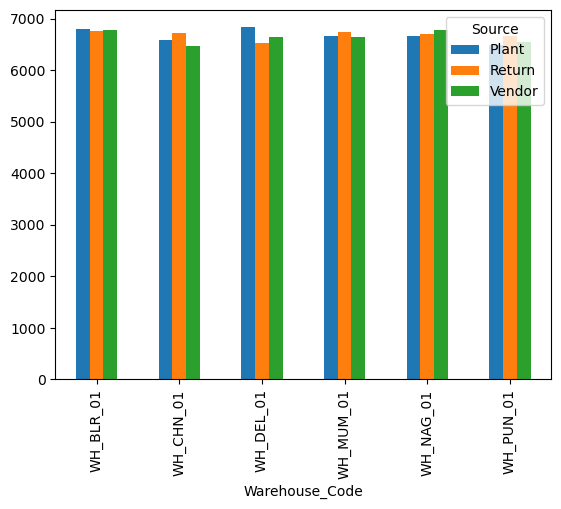

In [83]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Source']).plot(kind="bar")

In [84]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Source']).agg(['sum', 'min','max'])

Source,Plant,Return,Vendor
sum,40030,40116,39854
min,6487,6531,6469
max,6827,6763,6780


<Axes: xlabel='Source', ylabel='Warehouse_Code'>

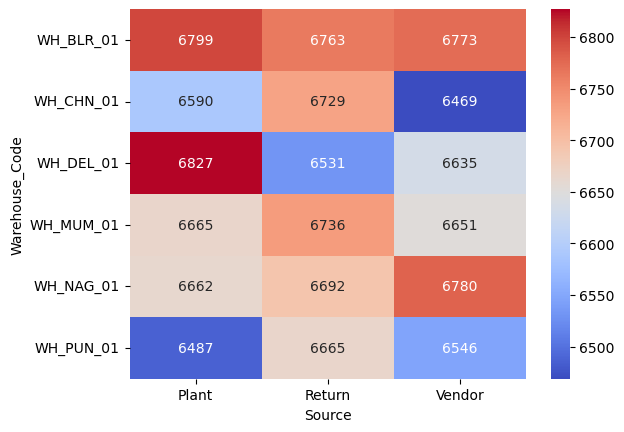

In [85]:
sns.heatmap(pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Source']),
           fmt = 'd', annot = True, cmap='coolwarm')

In [86]:
pd.crosstab(inventory_movement['Warehouse_Code'],inventory_movement['Destination'])

Destination,Customer,Plant,Warehouse Transfer
Warehouse_Code,,,
WH_BLR_01,6684,6885,6766
WH_CHN_01,6636,6540,6612
WH_DEL_01,6726,6639,6628
WH_MUM_01,6735,6709,6608
WH_NAG_01,6723,6687,6724
WH_PUN_01,6554,6623,6521


<Axes: xlabel='Destination', ylabel='Warehouse_Code'>

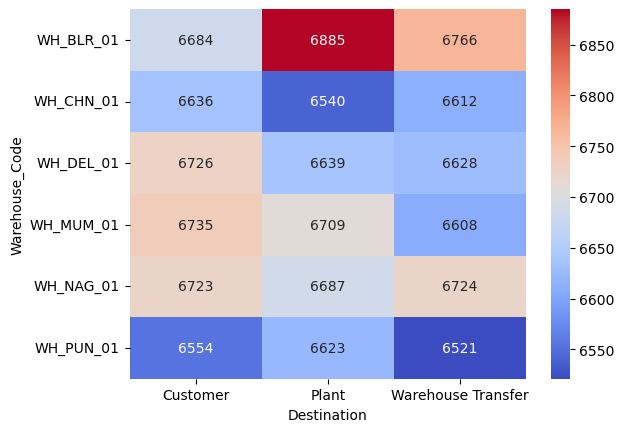

In [87]:
sns.heatmap(pd.crosstab(inventory_movement['Warehouse_Code'],inventory_movement['Destination']),
           annot = True, fmt = 'd', cmap ='coolwarm')

In [88]:
inventory_movement['Verification_Status'].value_counts()

Verification_Status
Verified    101899
Mismatch     12105
Pending       5996
Name: count, dtype: int64

In [89]:
pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Verification_Status'])

Verification_Status,Mismatch,Pending,Verified
Warehouse_Code,,,
WH_BLR_01,2090,1005,17240
WH_CHN_01,2053,992,16743
WH_DEL_01,2001,1008,16984
WH_MUM_01,1965,1002,17085
WH_NAG_01,2056,1034,17044
WH_PUN_01,1940,955,16803


<Axes: xlabel='Verification_Status', ylabel='Warehouse_Code'>

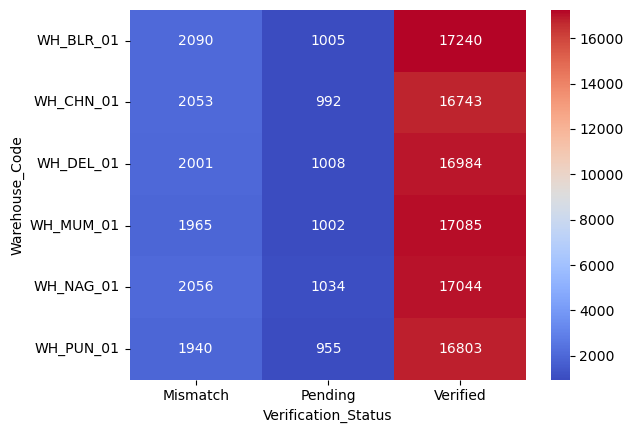

In [90]:
sns.heatmap(pd.crosstab(inventory_movement['Warehouse_Code'], inventory_movement['Verification_Status']),
           annot=True, fmt= "d", cmap='coolwarm')

In [91]:
inventory_movement.groupby('Movement_Type')['Movement_Quantity'].agg(['sum','min','max'])

,sum,min,max
Movement_Type,,,
Inward,1132625,1,54
Outward,1220659,1,55


<Axes: ylabel='Movement_Quantity'>

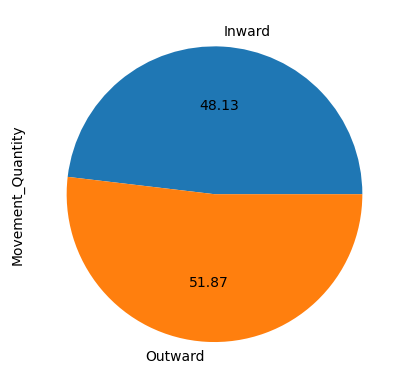

In [92]:
inventory_movement.groupby('Movement_Type')['Movement_Quantity'].sum().plot(kind='pie',autopct="%0.2f")

In [93]:
pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Source'])

Source,Plant,Return,Vendor
Movement_Type,,,
Inward,19357,19137,19184
Outward,20673,20979,20670


<Axes: xlabel='Source', ylabel='Movement_Type'>

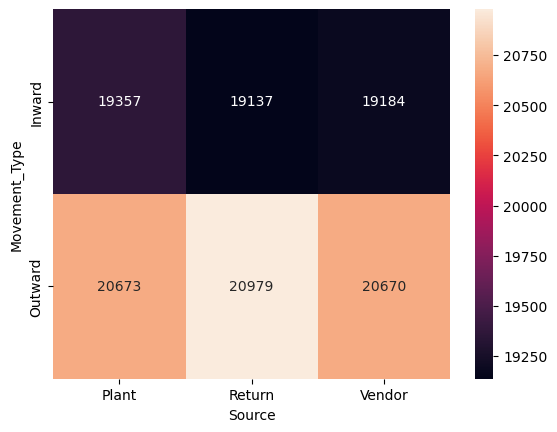

In [94]:
sns.heatmap(pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Source']),
           annot = True, fmt = 'd')

In [95]:
pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Destination'])

Destination,Customer,Plant,Warehouse Transfer
Movement_Type,,,
Inward,19315,19267,19096
Outward,20743,20816,20763


<Axes: xlabel='Destination', ylabel='Movement_Type'>

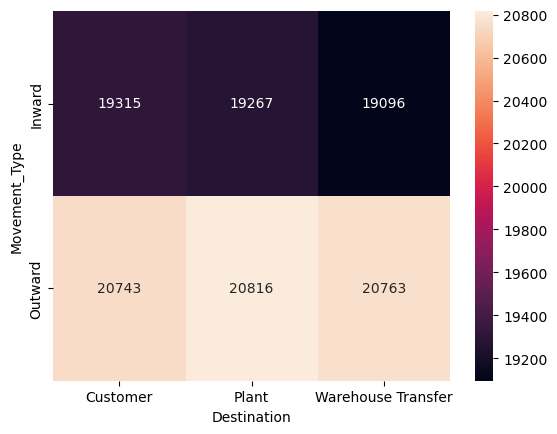

In [96]:
sns.heatmap(pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Destination']),
           annot = True, fmt = 'd')

In [97]:
pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Verification_Status'])

Verification_Status,Mismatch,Pending,Verified
Movement_Type,,,
Inward,5763,2863,49052
Outward,6342,3133,52847


In [98]:
pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Verification_Status']).sum()

Verification_Status
Mismatch     12105
Pending       5996
Verified    101899
dtype: int64

<Axes: xlabel='Verification_Status', ylabel='Movement_Type'>

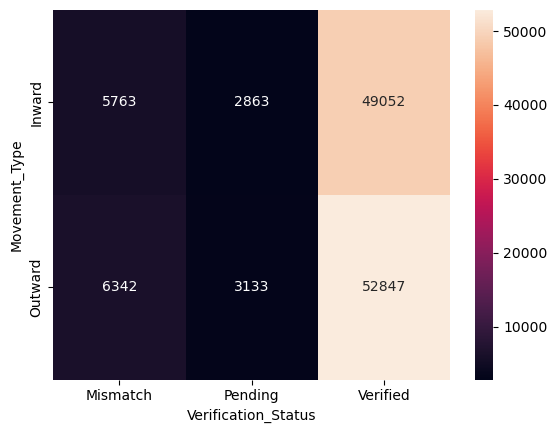

In [99]:
sns.heatmap(pd.crosstab(inventory_movement['Movement_Type'],inventory_movement['Verification_Status']),
           annot = True, fmt = 'd')

# Bivariate Analysis of 5th Table - "inventory_profiling"

In [100]:
inventory_profiling.sample(3)

,Profiling_ID,Item_ID,Item_Category,Priority_Level,Warehouse_Code,Storage_Zone,Movement_Velocity,Last_Profiled_Date
26485,PROF4026485,ITEM126485,Raw Material,High,WH_MUM_01,Zone B,Slow Moving,2023-05-15
28017,PROF4028017,ITEM128017,Finished Goods,Low,WH_CHN_01,Zone A,Slow Moving,2024-09-08
8734,PROF4008734,ITEM108734,Spare Parts,Medium,WH_MUM_01,Zone B,Slow Moving,2023-05-18


In [101]:
inventory_profiling.shape

(40000, 8)

In [102]:
inventory_profiling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Profiling_ID        40000 non-null  object
 1   Item_ID             40000 non-null  object
 2   Item_Category       40000 non-null  object
 3   Priority_Level      40000 non-null  object
 4   Warehouse_Code      40000 non-null  object
 5   Storage_Zone        40000 non-null  object
 6   Movement_Velocity   40000 non-null  object
 7   Last_Profiled_Date  40000 non-null  object
dtypes: object(8)
memory usage: 2.4+ MB


In [103]:
inventory_profiling['Last_Profiled_Date'] = pd.DatetimeIndex(inventory_profiling['Last_Profiled_Date'])

In [104]:
pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Storage_Zone'])

Storage_Zone,Overflow,Zone A,Zone B,Zone C
Warehouse_Code,,,,
WH_BLR_01,684,2368,1993,1655
WH_CHN_01,642,2287,2025,1632
WH_DEL_01,709,2283,2061,1692
WH_MUM_01,653,2381,2050,1644
WH_NAG_01,635,2358,2076,1606
WH_PUN_01,653,2265,1983,1665


In [105]:
pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Storage_Zone']).sum()

Storage_Zone
Overflow     3976
Zone A      13942
Zone B      12188
Zone C       9894
dtype: int64

<Axes: xlabel='Storage_Zone', ylabel='Warehouse_Code'>

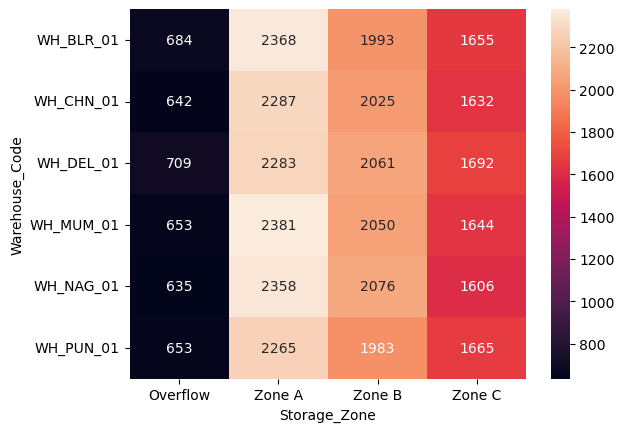

In [106]:
sns.heatmap(pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Storage_Zone']),
           annot=True, fmt='d')

In [107]:
inventory_profiling['Year'] = inventory_profiling['Last_Profiled_Date'].dt.year

In [108]:
pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Year'])

Year,2023,2024
Warehouse_Code,,
WH_BLR_01,3302,3398
WH_CHN_01,3218,3368
WH_DEL_01,3311,3434
WH_MUM_01,3362,3366
WH_NAG_01,3309,3366
WH_PUN_01,3344,3222


In [109]:
pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Year'] ).sum()

Year
2023    19846
2024    20154
dtype: int64

<Axes: xlabel='Year'>

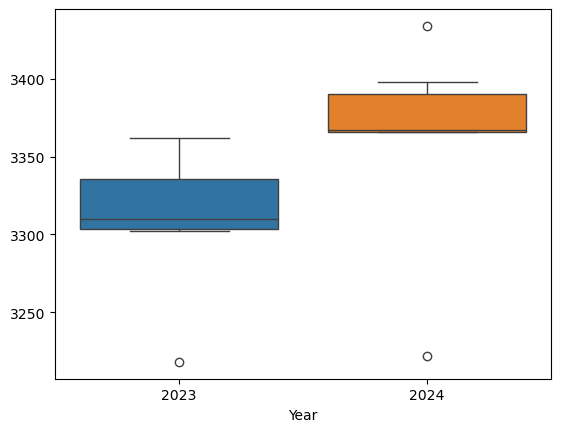

In [110]:
sns.boxplot(pd.crosstab(inventory_profiling['Warehouse_Code'],inventory_profiling['Year']))

In [111]:
pd.crosstab(inventory_profiling['Item_Category'],inventory_profiling['Storage_Zone'])

Storage_Zone,Overflow,Zone A,Zone B,Zone C
Item_Category,,,,
Consumables,415,1396,1189,1029
Finished Goods,1271,4412,3880,3193
Packaging,703,2546,2244,1772
Raw Material,1107,3940,3385,2703
Spare Parts,480,1648,1490,1197


In [112]:
inventory_profiling['Storage_Zone'].value_counts()

Storage_Zone
Zone A      13942
Zone B      12188
Zone C       9894
Overflow     3976
Name: count, dtype: int64

<Axes: xlabel='Storage_Zone', ylabel='Item_Category'>

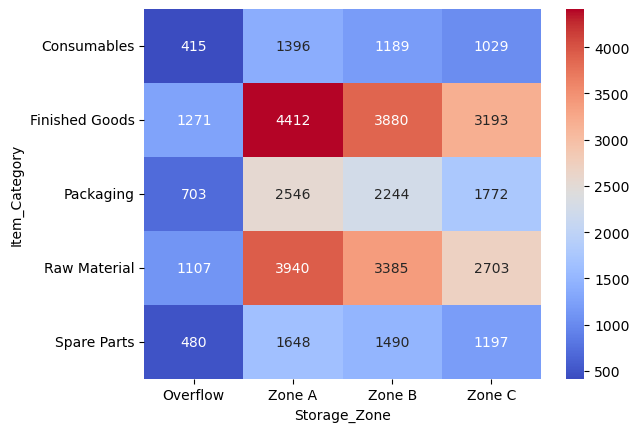

In [113]:
sns.heatmap(pd.crosstab(inventory_profiling['Item_Category'],inventory_profiling['Storage_Zone']),
           annot=True, fmt='d', cmap='coolwarm')

In [114]:
pd.crosstab(inventory_profiling['Priority_Level'],inventory_profiling['Storage_Zone'])

Storage_Zone,Overflow,Zone A,Zone B,Zone C
Priority_Level,,,,
High,1202,4213,3662,2902
Low,992,3461,3012,2480
Medium,1782,6268,5514,4512


In [115]:
pd.crosstab(inventory_profiling['Priority_Level'],inventory_profiling['Storage_Zone']).sum()

Storage_Zone
Overflow     3976
Zone A      13942
Zone B      12188
Zone C       9894
dtype: int64

<Axes: xlabel='Storage_Zone', ylabel='Priority_Level'>

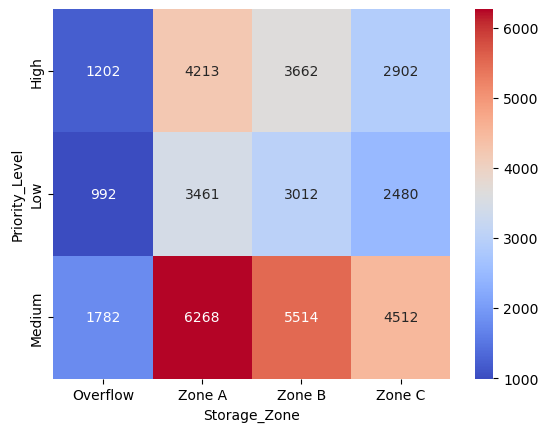

In [116]:
sns.heatmap(pd.crosstab(inventory_profiling['Priority_Level'],inventory_profiling['Storage_Zone']),
           annot=True, fmt='d', cmap='coolwarm')

# Bivariate Analysis of 6th Table - "inventory_validation"

In [117]:
inventory_validation.head(3)

,Validation_ID,Movement_ID,Validation_Date,Validation_Rule,Validation_Status,Validator,Remarks
0,VAL7000000,MOV3000004,2023-03-23,UOM consistency,Pass,auditor_suresh,NaN
1,VAL7000001,MOV3000012,2021-11-14,ERP posting validation,Pass,system_auto,NaN
2,VAL7000002,MOV3000022,2021-01-30,Document completeness,Pass,auditor_pooja,NaN


In [118]:
inventory_validation.shape

(20564, 7)

In [119]:
inventory_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20564 entries, 0 to 20563
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Validation_ID      20564 non-null  object
 1   Movement_ID        20564 non-null  object
 2   Validation_Date    20564 non-null  object
 3   Validation_Rule    20564 non-null  object
 4   Validation_Status  20564 non-null  object
 5   Validator          20564 non-null  object
 6   Remarks            4496 non-null   object
dtypes: object(7)
memory usage: 1.1+ MB


In [120]:
inventory_validation['Validation_Date'] = pd.DatetimeIndex(inventory_validation['Validation_Date'])

In [121]:
pd.crosstab(inventory_validation['Validation_Rule'],inventory_validation['Validation_Status'])

Validation_Status,Fail,Pass
Validation_Rule,,
Document completeness,939,3240
ERP posting validation,846,3145
Quantity tolerance check,918,3268
UOM consistency,908,3231
Warehouse-location match,885,3184


In [122]:
pd.crosstab(inventory_validation['Validation_Rule'],inventory_validation['Validation_Status']).sum()

Validation_Status
Fail     4496
Pass    16068
dtype: int64

<Axes: xlabel='Validation_Status', ylabel='Validation_Rule'>

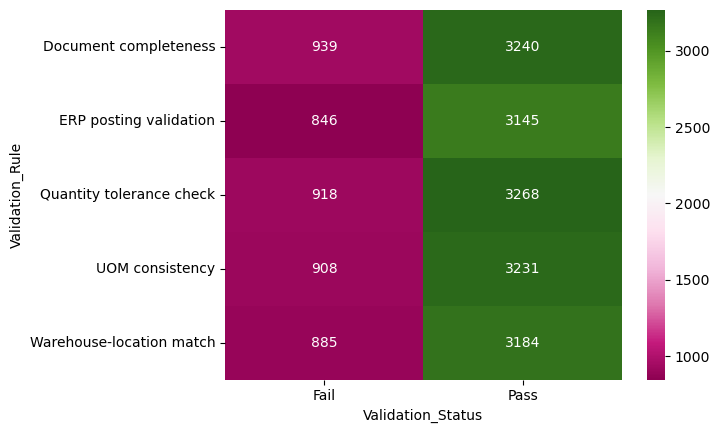

In [123]:
sns.heatmap(pd.crosstab(inventory_validation['Validation_Rule'],inventory_validation['Validation_Status']),
           annot=True, fmt='d', cmap='PiYG')

In [124]:
pd.crosstab(inventory_validation['Validator'],inventory_validation['Validation_Status'])

Validation_Status,Fail,Pass
Validator,,
auditor_neha,925,3157
auditor_pooja,921,3211
auditor_raj,877,3183
auditor_suresh,856,3309
system_auto,917,3208


<Axes: xlabel='Validation_Status', ylabel='Validator'>

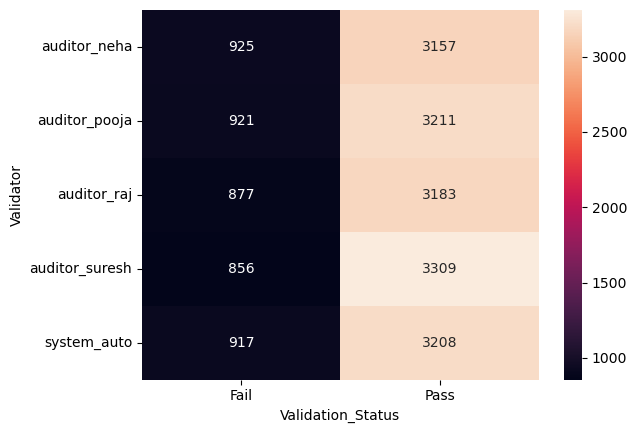

In [125]:
sns.heatmap(pd.crosstab(inventory_validation['Validator'],inventory_validation['Validation_Status']),
           annot=True, fmt='d')

In [126]:
pd.crosstab(inventory_validation['Validator'],inventory_validation['Validation_Rule'])

Validation_Rule,Document completeness,ERP posting validation,Quantity tolerance check,UOM consistency,Warehouse-location match
Validator,,,,,
auditor_neha,857,787,835,817,786
auditor_pooja,812,772,857,858,833
auditor_raj,820,830,819,822,769
auditor_suresh,843,821,855,804,842
system_auto,847,781,820,838,839


In [127]:
pd.crosstab(inventory_validation['Validator'],inventory_validation['Validation_Rule']).agg(['min','max'])

Validation_Rule,Document completeness,ERP posting validation,Quantity tolerance check,UOM consistency,Warehouse-location match
min,812,772,819,804,769
max,857,830,857,858,842


<Axes: xlabel='Validator', ylabel='Validation_Rule'>

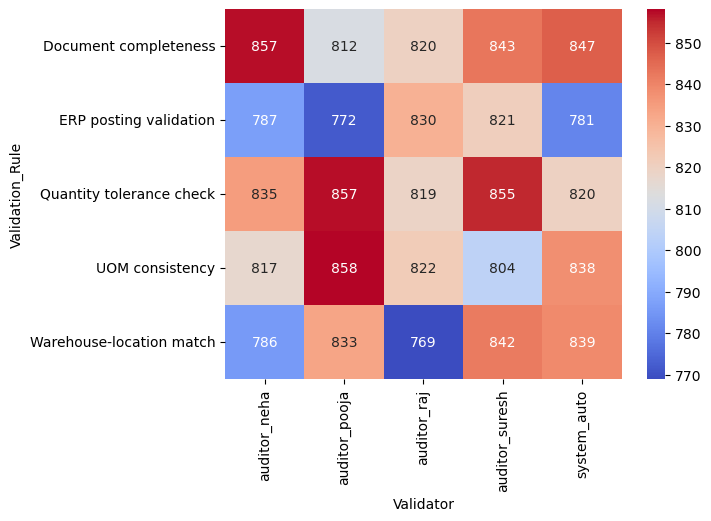

In [128]:
sns.heatmap(pd.crosstab(inventory_validation['Validation_Rule'],inventory_validation['Validator']),
           annot=True, fmt='d', cmap='coolwarm')

# Bivariate Analysis of 7th Table - "task_allocation"

In [129]:
task_allocation.sample(3)

,Task_ID,Task_Date,Item_ID,Warehouse_Code,Task_Type,Assigned_Staff,Assigned_Quantity,Task_Status
26320,TASK2026320,2021-08-02,ITEM121187,WH_DEL_01,Cycle Count,staff_vikas,19,Completed
97031,TASK2097031,2023-09-30,ITEM107064,WH_BLR_01,Inbound Verification,staff_priya,7,Completed
92263,TASK2092263,2024-01-24,ITEM116197,WH_BLR_01,Cycle Count,staff_sneha,15,Completed


In [130]:
task_allocation.shape

(100000, 8)

In [131]:
task_allocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Task_ID            100000 non-null  object
 1   Task_Date          100000 non-null  object
 2   Item_ID            100000 non-null  object
 3   Warehouse_Code     100000 non-null  object
 4   Task_Type          100000 non-null  object
 5   Assigned_Staff     100000 non-null  object
 6   Assigned_Quantity  100000 non-null  int64 
 7   Task_Status        100000 non-null  object
dtypes: int64(1), object(7)
memory usage: 6.1+ MB


In [132]:
task_allocation['Task_Date'] = pd.DatetimeIndex(task_allocation['Task_Date'])

In [133]:
pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Type'])

Task_Type,Cycle Count,Inbound Verification,Outbound Dispatch,Packing,Picking,Putaway,Stock Transfer
Warehouse_Code,,,,,,,
WH_BLR_01,2423,2367,2356,2363,2441,2444,2427
WH_CHN_01,2356,2396,2357,2340,2433,2384,2365
WH_DEL_01,2322,2329,2435,2391,2421,2432,2289
WH_MUM_01,2450,2372,2313,2392,2376,2377,2426
WH_NAG_01,2418,2417,2447,2264,2502,2345,2433
WH_PUN_01,2274,2386,2397,2335,2345,2430,2230


In [134]:
pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Type']).sum()

Task_Type
Cycle Count             14243
Inbound Verification    14267
Outbound Dispatch       14305
Packing                 14085
Picking                 14518
Putaway                 14412
Stock Transfer          14170
dtype: int64

<Axes: xlabel='Warehouse_Code', ylabel='Task_Type'>

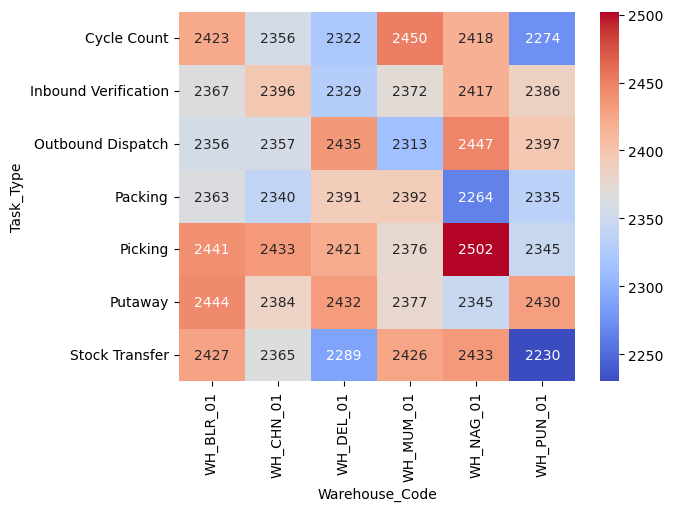

In [135]:
sns.heatmap(pd.crosstab(task_allocation['Task_Type'],task_allocation['Warehouse_Code']),
           annot=True, fmt='d', cmap='coolwarm')

In [136]:
pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Assigned_Staff'])

Assigned_Staff,staff_ajay,staff_amit,staff_kiran,staff_priya,staff_rohit,staff_sneha,staff_sonal,staff_vikas
Warehouse_Code,,,,,,,,
WH_BLR_01,2990,2078,1688,2035,2506,2335,1685,1504
WH_CHN_01,2977,2013,1628,2045,2511,2285,1667,1505
WH_DEL_01,2928,1999,1632,1987,2513,2339,1722,1499
WH_MUM_01,3070,2001,1707,2009,2507,2327,1623,1462
WH_NAG_01,3004,1970,1701,2029,2573,2364,1638,1547
WH_PUN_01,2975,1945,1635,2002,2440,2354,1611,1435


<Axes: xlabel='Warehouse_Code', ylabel='Assigned_Staff'>

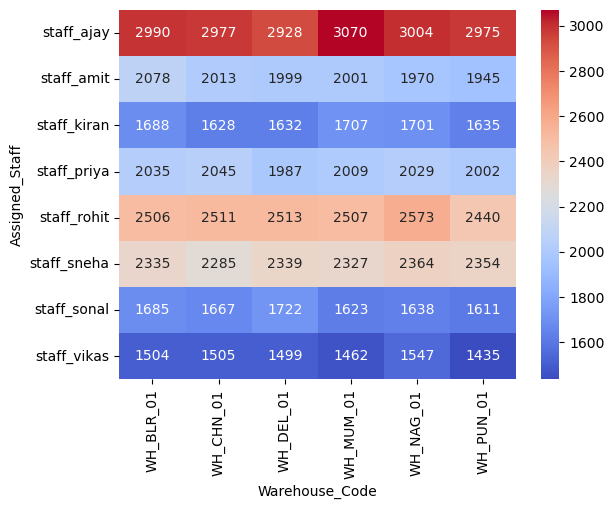

In [137]:
sns.heatmap(pd.crosstab(task_allocation['Assigned_Staff'],task_allocation['Warehouse_Code']),
           annot=True, fmt = 'd', cmap='coolwarm')

In [138]:
task_allocation.groupby('Warehouse_Code')['Assigned_Quantity'].sum()

Warehouse_Code
WH_BLR_01    337033
WH_CHN_01    338219
WH_DEL_01    335503
WH_MUM_01    337321
WH_NAG_01    334354
WH_PUN_01    332746
Name: Assigned_Quantity, dtype: int64

<Axes: xlabel='Warehouse_Code', ylabel='Assigned_Quantity'>

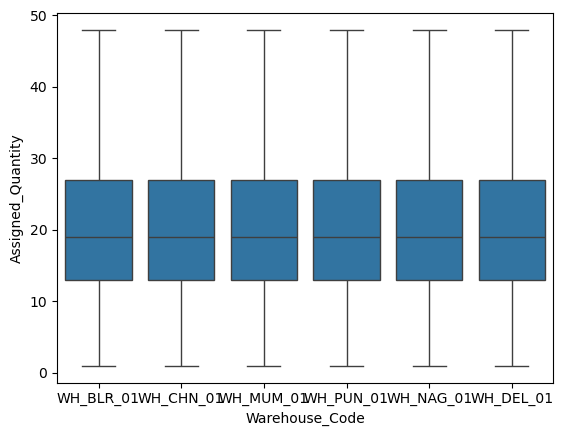

In [139]:
sns.boxplot(x=task_allocation['Warehouse_Code'],
           y=task_allocation['Assigned_Quantity'])

In [140]:
pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Status'])

Task_Status,Cancelled,Completed,Pending
Warehouse_Code,,,
WH_BLR_01,890,14206,1725
WH_CHN_01,820,14145,1666
WH_DEL_01,853,14096,1670
WH_MUM_01,839,14181,1686
WH_NAG_01,846,14310,1670
WH_PUN_01,844,13959,1594


<Axes: xlabel='Task_Status', ylabel='Warehouse_Code'>

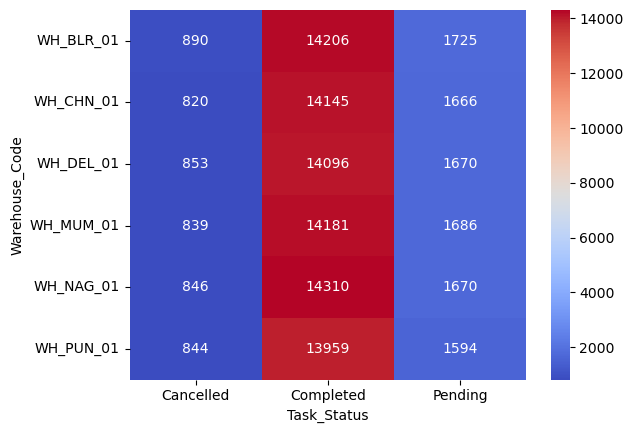

In [141]:
sns.heatmap(pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Status']),
           annot=True, fmt = 'd', cmap='coolwarm')

In [142]:
task_allocation['Task_Year'] = task_allocation['Task_Date'].dt.year

In [143]:
pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Year'])

Task_Year,2021,2022,2023,2024
Warehouse_Code,,,,
WH_BLR_01,4168,4199,4261,4193
WH_CHN_01,4137,4196,4168,4130
WH_DEL_01,4196,4088,4194,4141
WH_MUM_01,4236,4203,4087,4180
WH_NAG_01,4195,4205,4223,4203
WH_PUN_01,4151,3981,4188,4077


<Axes: xlabel='Task_Year', ylabel='Warehouse_Code'>

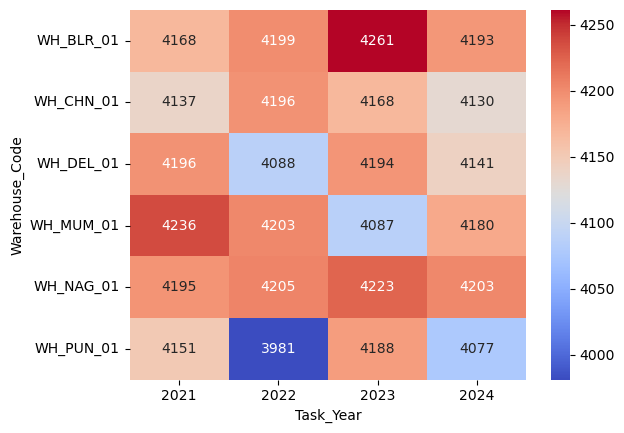

In [144]:
sns.heatmap(pd.crosstab(task_allocation['Warehouse_Code'],task_allocation['Task_Year']),
           annot=True, fmt = 'd', cmap='coolwarm')

In [145]:
pd.crosstab(task_allocation['Task_Type'],task_allocation['Assigned_Staff'])

Assigned_Staff,staff_ajay,staff_amit,staff_kiran,staff_priya,staff_rohit,staff_sneha,staff_sonal,staff_vikas
Task_Type,,,,,,,,
Cycle Count,2607,1748,1458,1646,2134,2006,1384,1260
Inbound Verification,2547,1710,1426,1716,2107,2015,1488,1258
Outbound Dispatch,2564,1717,1444,1745,2202,1921,1424,1288
Packing,2486,1678,1368,1710,2144,1969,1440,1290
Picking,2584,1735,1446,1794,2180,2008,1465,1306
Putaway,2599,1757,1482,1759,2138,2032,1396,1249
Stock Transfer,2557,1661,1367,1737,2145,2053,1349,1301


In [146]:
pd.crosstab(task_allocation['Task_Type'],task_allocation['Assigned_Staff']).agg(['min','max'])

Assigned_Staff,staff_ajay,staff_amit,staff_kiran,staff_priya,staff_rohit,staff_sneha,staff_sonal,staff_vikas
min,2486,1661,1367,1646,2107,1921,1349,1249
max,2607,1757,1482,1794,2202,2053,1488,1306


<Axes: xlabel='Assigned_Staff', ylabel='Task_Type'>

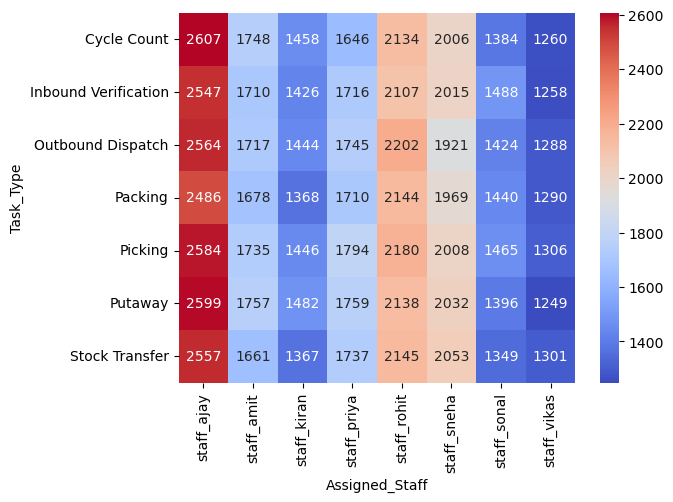

In [147]:
sns.heatmap(pd.crosstab(task_allocation['Task_Type'],task_allocation['Assigned_Staff']),
           annot=True, fmt='d', cmap='coolwarm')

In [148]:
pd.crosstab(task_allocation['Task_Type'],task_allocation['Task_Status'])

Task_Status,Cancelled,Completed,Pending
Task_Type,,,
Cycle Count,736,12059,1448
Inbound Verification,745,12076,1446
Outbound Dispatch,746,12179,1380
Packing,705,12012,1368
Picking,750,12283,1485
Putaway,687,12304,1421
Stock Transfer,723,11984,1463


<Axes: xlabel='Task_Status', ylabel='Task_Type'>

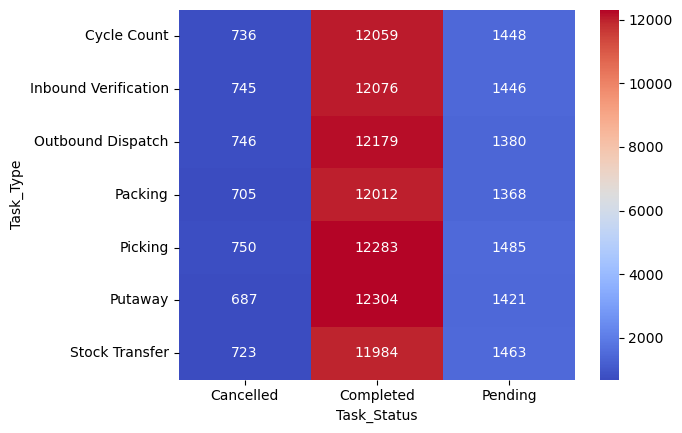

In [149]:
sns.heatmap(pd.crosstab(task_allocation['Task_Type'],task_allocation['Task_Status']),
           annot=True, fmt='d', cmap='coolwarm')

In [150]:
task_allocation.groupby('Assigned_Staff')['Assigned_Quantity'].agg(['sum','min','max','count'])

,sum,min,max,count
Assigned_Staff,,,,
staff_ajay,361343,1,48,17944
staff_amit,243491,1,48,12006
staff_kiran,200756,1,48,9991
staff_priya,243836,1,48,12107
staff_rohit,301013,1,48,15050
staff_sneha,282569,1,48,14004
staff_sonal,202219,1,48,9946
staff_vikas,179949,1,48,8952


<Axes: xlabel='Assigned_Staff'>

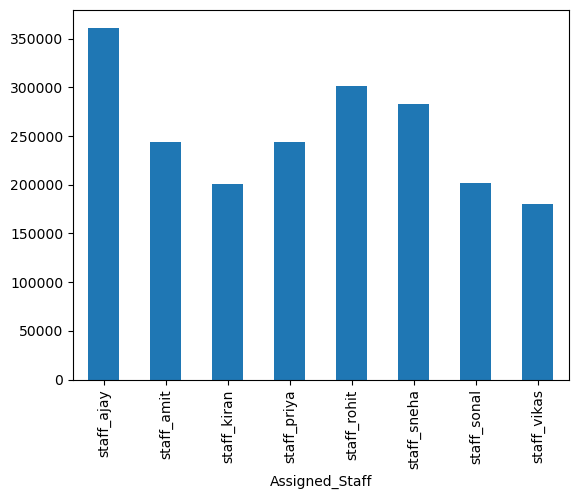

In [151]:
task_allocation.groupby('Assigned_Staff')['Assigned_Quantity'].sum().plot(kind='bar')

<Axes: xlabel='Assigned_Quantity', ylabel='Assigned_Staff'>

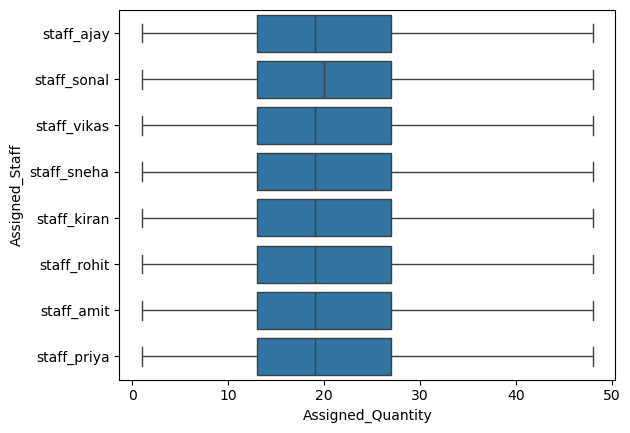

In [152]:
sns.boxplot(x=task_allocation['Assigned_Quantity'], y=task_allocation['Assigned_Staff'])

In [153]:
pd.crosstab(task_allocation['Assigned_Staff'],task_allocation['Task_Status'])

Task_Status,Cancelled,Completed,Pending
Assigned_Staff,,,
staff_ajay,879,15283,1782
staff_amit,559,10240,1207
staff_kiran,502,8470,1019
staff_priya,637,10316,1154
staff_rohit,788,12753,1509
staff_sneha,753,11868,1383
staff_sonal,542,8347,1057
staff_vikas,432,7620,900


<Axes: xlabel='Task_Status', ylabel='Assigned_Staff'>

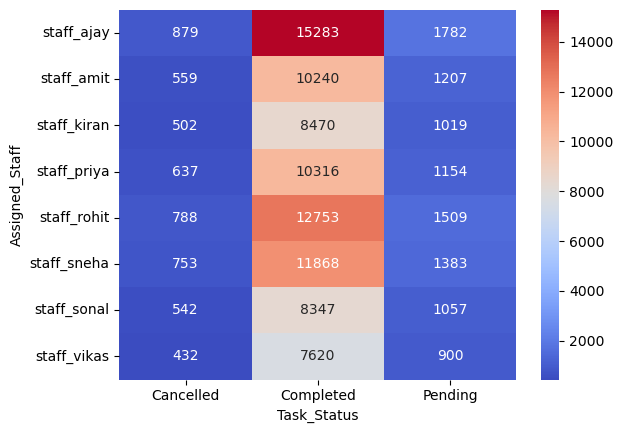

In [154]:
sns.heatmap(pd.crosstab(task_allocation['Assigned_Staff'],task_allocation['Task_Status']),
           annot=True, fmt = 'd', cmap = 'coolwarm')

In [155]:
task_allocation.groupby('Task_Status')['Assigned_Quantity'].agg(['sum','min','max'])

,sum,min,max
Task_Status,,,
Cancelled,102218,1,48
Completed,1710367,1,48
Pending,202591,1,48


<Axes: xlabel='Task_Status'>

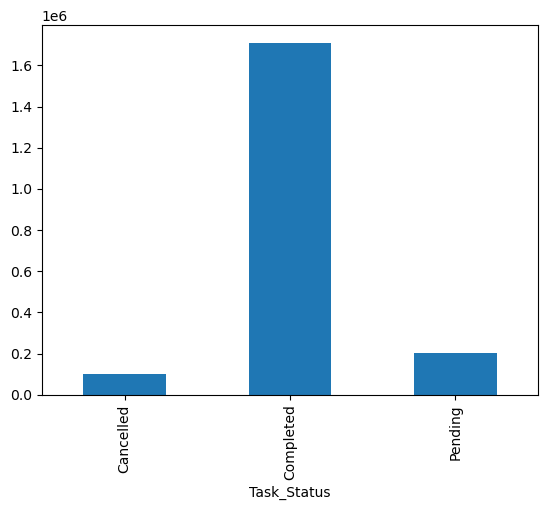

In [156]:
task_allocation.groupby('Task_Status')['Assigned_Quantity'].sum().plot(kind='bar')

<Axes: xlabel='Task_Status', ylabel='Assigned_Quantity'>

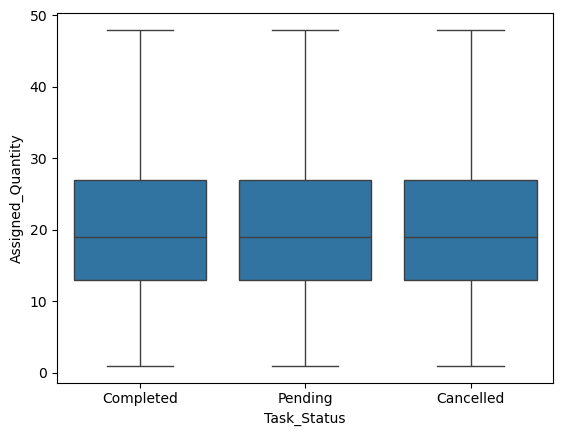

In [157]:
sns.boxplot(x=task_allocation['Task_Status'], y=task_allocation['Assigned_Quantity'])

In [158]:
pd.pivot_table(task_allocation, values='Assigned_Quantity', index='Task_Status', aggfunc='sum')

,Assigned_Quantity
Task_Status,
Cancelled,102218
Completed,1710367
Pending,202591


# Key Business Insights

- Examined relationships between important business variables.
- Identified positive and negative correlations.
- Compared distributions across different categories.
- Detected patterns useful for business decision-making.

# Conclusion

Bivariate Analysis helps understand how two variables interact and provides meaningful insights that support operational and strategic decisions.